In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [39]:
df.head(10)



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [29]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity_<1H OCEAN,bool


In [40]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


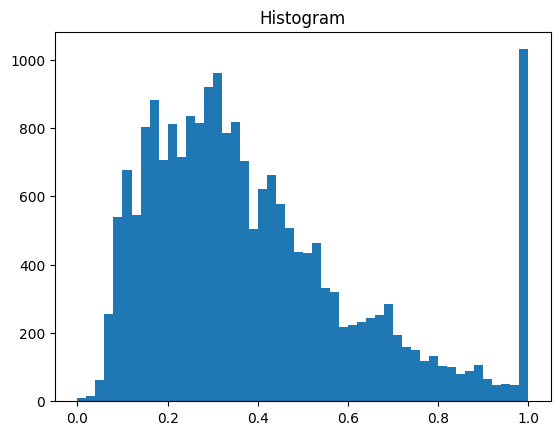

In [54]:
plt.hist(df["median_house_value"], bins=50)
plt.title("Histogram")
plt.show()




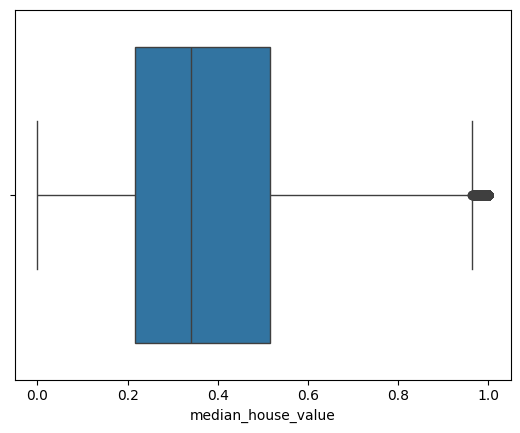

In [55]:
sns.boxplot(x=df["median_house_value"])
plt.show()

In [59]:
missing_percent = df.isnull().mean() * 100
print(missing_percent)


longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64


In [41]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [60]:
df = pd.get_dummies(df, columns=["ocean_proximity"])


In [42]:
numeric_cols = df.select_dtypes(include=np.number).columns

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,NEAR BAY
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,NEAR BAY
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,NEAR BAY
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,NEAR BAY
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,0.324701,0.737513,0.470588,0.042296,0.057883,0.023599,0.054103,0.073130,0.130105,INLAND
20636,0.312749,0.738576,0.333333,0.017676,0.023122,0.009894,0.018582,0.141853,0.128043,INLAND
20637,0.311753,0.732200,0.313725,0.057277,0.075109,0.028140,0.071041,0.082764,0.159383,INLAND
20638,0.301793,0.732200,0.333333,0.047256,0.063315,0.020684,0.057227,0.094295,0.143713,INLAND


In [43]:

original_df_for_binning = pd.read_csv(url)

df["income_cat"] = pd.cut(original_df_for_binning["median_income"],
                          bins=[0,1.5,3,4.5,6,np.inf],
                          labels=[1,2,3,4,5],
                          include_lowest=True) # Added include_lowest for robustness

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2)

for train_idx, test_idx in split.split(df, df["income_cat"]):
    strat_train = df.loc[train_idx]
    strat_test = df.loc[test_idx]

df.drop("income_cat", axis=1, inplace=True)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,NEAR BAY
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,NEAR BAY
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,NEAR BAY
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,NEAR BAY
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,0.324701,0.737513,0.470588,0.042296,0.057883,0.023599,0.054103,0.073130,0.130105,INLAND
20636,0.312749,0.738576,0.333333,0.017676,0.023122,0.009894,0.018582,0.141853,0.128043,INLAND
20637,0.311753,0.732200,0.313725,0.057277,0.075109,0.028140,0.071041,0.082764,0.159383,INLAND
20638,0.301793,0.732200,0.333333,0.047256,0.063315,0.020684,0.057227,0.094295,0.143713,INLAND


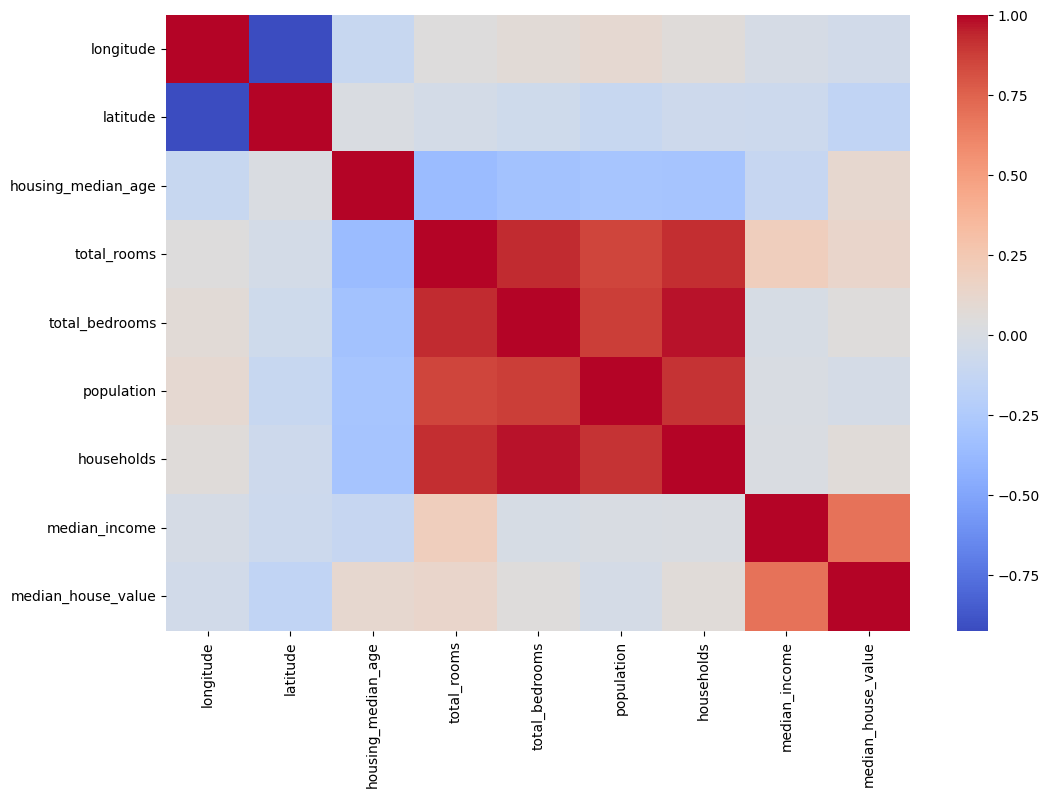

In [45]:
# Select only numeric and boolean columns for correlation calculation
numeric_df = df.select_dtypes(include=['number', 'bool'])
corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

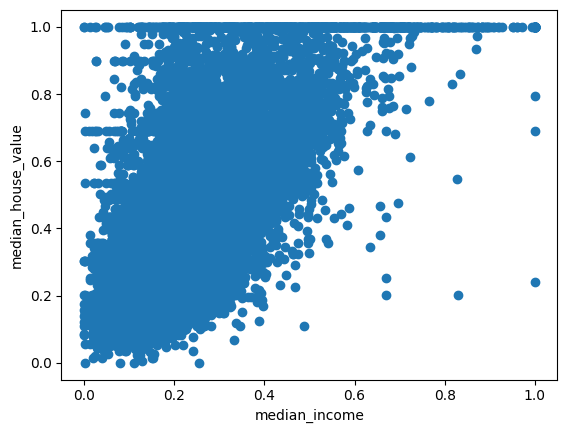

In [46]:
plt.scatter(df["median_income"], df["median_house_value"])
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.show()


In [47]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,0.729084,0.018066,0.627451,0.079455,0.097145,0.064380,0.102286,0.190322,0.181445,NEAR OCEAN
8267,0.616534,0.130712,0.941176,0.085966,0.121974,0.036744,0.124157,0.228452,0.756906,NEAR OCEAN
17445,0.385458,0.225292,0.058824,0.048197,0.051210,0.025561,0.055090,0.252162,0.324949,NEAR OCEAN
14265,0.721116,0.015940,0.686275,0.036090,0.056797,0.039659,0.058214,0.099488,0.161651,NEAR OCEAN
2271,0.453187,0.450584,0.823529,0.060532,0.066729,0.024412,0.062325,0.210638,0.168043,INLAND
...,...,...,...,...,...,...,...,...,...,...
11284,0.636454,0.131775,0.666667,0.033776,0.031037,0.018358,0.035520,0.404829,0.441650,<1H OCEAN
11964,0.689243,0.157279,0.627451,0.078386,0.088299,0.049048,0.073672,0.175867,0.170723,INLAND
5390,0.594622,0.158342,0.686275,0.053385,0.088144,0.049133,0.086499,0.167894,0.427011,<1H OCEAN
860,0.238048,0.535600,0.274510,0.090874,0.092489,0.049721,0.091761,0.359947,0.553608,<1H OCEAN


In [48]:
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,0.531873,0.374070,0.470588,0.038227,0.067349,0.038930,0.058872,0.081468,0.067424,INLAND
3024,0.487052,0.276302,0.568627,0.074800,0.067349,0.043779,0.095872,0.140095,0.063507,INLAND
15663,0.190239,0.558980,1.000000,0.097360,0.067349,0.036632,0.158198,0.205528,1.000000,NEAR BAY
20484,0.560757,0.184910,0.313725,0.077547,0.067349,0.047703,0.081237,0.361216,0.419794,<1H OCEAN
9814,0.241036,0.433581,0.647059,0.059744,0.067349,0.029709,0.070219,0.222418,0.542268,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
15362,0.710159,0.087141,0.294118,0.080447,0.074643,0.037781,0.074165,0.283106,0.511959,<1H OCEAN
16623,0.350598,0.299681,0.529412,0.109899,0.137337,0.046162,0.115770,0.153563,0.519175,NEAR OCEAN
18086,0.229084,0.506908,0.470588,0.104507,0.083333,0.044340,0.093241,0.602054,1.000000,<1H OCEAN
2144,0.457171,0.449522,0.686275,0.063711,0.072160,0.034306,0.077783,0.157591,0.118146,INLAND


In [49]:
corr_target = corr["median_house_value"].sort_values(ascending=False)

print("Top 3 Positive:")
print(corr_target[1:4])

print("Most Negative:")
print(corr_target.tail(1))


Top 3 Positive:
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
Name: median_house_value, dtype: float64
Most Negative:
latitude   -0.14416
Name: median_house_value, dtype: float64


In [51]:
scaler = StandardScaler()

# Select all numeric and boolean columns for X, excluding the target variable
X = df.select_dtypes(include=['number', 'bool']).drop("median_house_value", axis=1)
y = df["median_house_value"]

X_scaled = scaler.fit_transform(X)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [53]:
pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)


RMSE: 0.14666573229153748
MAE: 0.10682529892256654
R2 Score: 0.6138664756435175
